# IVN Graph Visualization Notebook

Notebook này giúp **visualize chi tiết cấu trúc graph hiện tại** theo đúng pipeline bạn đang dùng:

- **1 graph = 1 window**
- **1 node = 1 CAN message**
- **4 loại quan hệ (edge types)**:
  - `0 = temporal`
  - `1 = same_id`
  - `2 = payload_sim`
  - `3 = timing_aff`

Notebook hỗ trợ:
- đọc `graph_summary.json`, `graph_metadata.json`, `graph_index_*.parquet/csv`
- load **một graph cụ thể** từ shard
- hiển thị **node table** và **edge table**
- visualize:
  - toàn graph
  - từng relation riêng
  - timeline theo thứ tự message
  - adjacency matrix theo relation
  - ego-subgraph quanh một node
  - phân bố edge attributes

> Chỉ cần sửa `GRAPH_ROOT` cho đúng thư mục graph của bạn rồi chạy lần lượt.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')
print(sys.path)

['/home/hieutt/CAN-SupCon-IDS/notebooks', '/home/hieutt/miniconda3/envs/torchtf/lib/python39.zip', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/lib-dynload', '', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages', '../']


In [2]:
from pathlib import Path
import json
import math
import random
from typing import Dict, Any, List, Optional

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import networkx as nx

from IPython.display import display, Markdown

sns.set_context("talk")
sns.set_style("whitegrid")

# ====== EDIT THIS PATH ======
GRAPH_ROOT = Path("../data/2017-subaru-forester/graphs_v1_small")

# Nếu bạn muốn cố định một graph để demo:
DEFAULT_SPLIT = "test"
DEFAULT_GRAPH_INDEX = 0

print("GRAPH_ROOT =", GRAPH_ROOT.resolve())


GRAPH_ROOT = /home/hieutt/CAN-SupCon-IDS/data/2017-subaru-forester/graphs_v1_small


In [3]:
RELATION_COLORS = {
    "temporal": "#1f77b4",    # blue
    "same_id": "#d62728",     # red
    "payload_sim": "#2ca02c", # green
    "timing_aff": "#9467bd",  # purple
}

EDGE_ATTR_NAMES = [
    "log_dt_abs",
    "same_id_flag",
    "payload_l1_norm",
    "payload_hamming_norm",
    "index_gap_norm",
    "timing_diff_abs",
]


## 1. Load metadata và dataset summary

In [4]:
def load_json(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_table(base_path: Path) -> pd.DataFrame:
    parquet_path = base_path.with_suffix(".parquet")
    csv_path = base_path.with_suffix(".csv")
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f"Cannot find {parquet_path} or {csv_path}")

graph_metadata = load_json(GRAPH_ROOT / "graph_metadata.json")
graph_summary = load_json(GRAPH_ROOT / "graph_summary.json")

display(Markdown("### graph_metadata.json"))
display(pd.json_normalize(graph_metadata, sep="."))

display(Markdown("### graph_summary.json"))
display(pd.json_normalize(graph_summary, sep="."))


### graph_metadata.json

,node_feature_cols,graphs_per_shard,temporal_k,same_id_k,payload_topk,timing_topk,relation_to_index.temporal,relation_to_index.same_id,relation_to_index.payload_sim,relation_to_index.timing_aff,index_to_relation.0,index_to_relation.1,index_to_relation.2,index_to_relation.3
0,"[id_norm, byte_0_norm, byte_1_norm, byte_2_nor...",2000,1,1,1,1,0,1,2,3,temporal,same_id,payload_sim,timing_aff


### graph_summary.json

,input_dir,output_dir,splits.train.num_graphs,splits.train.num_shards,splits.train.label_counts.normal,splits.train.label_counts.combined,splits.train.label_counts.dos,splits.train.label_counts.fuzzing,splits.train.label_counts.gear,splits.train.label_counts.interval,...,splits.test.label_counts.rpm,splits.test.label_counts.speed,splits.test.label_counts.standstill,splits.test.label_counts.systematic,splits.test.avg_num_nodes,splits.test.avg_num_edges,splits.test.edge_relation_counts.temporal,splits.test.edge_relation_counts.same_id,splits.test.edge_relation_counts.payload_sim,splits.test.edge_relation_counts.timing_aff
0,data/2017-subaru-forester/preprocessed_v3,data/2017-subaru-forester/graphs_v1_small,94610,48,41869,13372,2003,2591,2114,19087,...,1328,1594,617,987,64.0,311.611263,3973788,2162084,1673292,2018432


In [5]:
def load_graph_index(split: str) -> pd.DataFrame:
    df = load_table(GRAPH_ROOT / f"graph_index_{split}")
    return df

split_indexes = {}
for split in ["train", "val", "test"]:
    try:
        split_indexes[split] = load_graph_index(split)
        print(f"{split}: {len(split_indexes[split])} graphs")
    except FileNotFoundError:
        print(f"{split}: not found")

if split_indexes:
    summary_rows = []
    for split, df in split_indexes.items():
        row = {
            "split": split,
            "num_graphs": len(df),
            "avg_num_nodes": df["num_nodes"].mean(),
            "avg_num_edges": df["num_edges"].mean(),
        }
        label_counts = df["window_label"].value_counts().to_dict()
        row.update({f"label::{k}": v for k, v in label_counts.items()})
        summary_rows.append(row)
    display(pd.DataFrame(summary_rows).fillna(0))


train: 94610 graphs
val: 31536 graphs
test: 31538 graphs


,split,num_graphs,avg_num_nodes,avg_num_edges,label::normal,label::interval,label::combined,label::speed,label::rpm,label::systematic,label::fuzzing,label::gear,label::dos,label::standstill
0,train,94610,64.0,311.658133,41869,19087,13372,4781,3982,2959,2591,2114,2003,1852
1,val,31536,64.0,311.642250,13956,6362,4457,1594,1327,986,864,705,668,617
2,test,31538,64.0,311.611263,13957,6363,4457,1594,1328,987,864,704,667,617


## 2. Helper functions để load một graph từ shard

In [6]:
def list_shard_files(split: str) -> List[Path]:
    split_dir = GRAPH_ROOT / split
    return sorted(split_dir.glob(f"graphs_{split}_shard*.pt"))

def load_shard(split: str, shard_id: int) -> List[Dict[str, Any]]:
    shard_path = GRAPH_ROOT / split / f"graphs_{split}_shard{int(shard_id):05d}.pt"
    if not shard_path.exists():
        raise FileNotFoundError(f"Shard not found: {shard_path}")
    return torch.load(shard_path, map_location="cpu", weights_only=False)

def load_graph_from_index_row(row: pd.Series) -> Dict[str, Any]:
    split = str(row["split"])
    shard_id = int(row["shard_id"])
    graph_id = str(row["graph_id"])
    shard_graphs = load_shard(split, shard_id)
    for g in shard_graphs:
        if str(g["graph_id"]) == graph_id:
            return g
    raise KeyError(f"graph_id={graph_id} not found in split={split}, shard_id={shard_id}")

def sample_graph(split: str = "test", label: Optional[str] = None, random_state: int = 0) -> Dict[str, Any]:
    df = load_graph_index(split)
    if label is not None:
        df = df[df["window_label"] == label].copy()
        if len(df) == 0:
            raise ValueError(f"No graphs found for split={split}, label={label}")
    row = df.sample(1, random_state=random_state).iloc[0]
    return load_graph_from_index_row(row)

def get_graph_by_position(split: str, idx: int) -> Dict[str, Any]:
    df = load_graph_index(split).reset_index(drop=True)
    if idx < 0 or idx >= len(df):
        raise IndexError(f"idx={idx} out of range for split={split}, len={len(df)}")
    row = df.iloc[idx]
    return load_graph_from_index_row(row)

def relation_name_from_index(rel_idx: int) -> str:
    idx2rel = graph_metadata["index_to_relation"]
    return idx2rel[str(int(rel_idx))] if isinstance(list(idx2rel.keys())[0], str) else idx2rel[int(rel_idx)]


## 3. Chuyển graph thành bảng node/edge dễ đọc

In [7]:
def graph_to_node_df(graph: Dict[str, Any]) -> pd.DataFrame:
    node_feature_cols = graph_metadata["node_feature_cols"]
    x = graph["x"].cpu().numpy()
    N = x.shape[0]

    df = pd.DataFrame(x, columns=node_feature_cols)
    df.insert(0, "node_idx", np.arange(N))
    if "id_index" in graph:
        df["id_index"] = graph["id_index"].cpu().numpy()
    if "arbitration_id" in graph:
        df["arbitration_id"] = graph["arbitration_id"].cpu().numpy()
    if "timestamp" in graph:
        df["timestamp"] = graph["timestamp"].cpu().numpy()
    if "msg_idx_in_file" in graph:
        df["msg_idx_in_file"] = graph["msg_idx_in_file"].cpu().numpy()

    # Sắp lại vài cột quan trọng lên đầu
    front = [c for c in ["node_idx", "msg_idx_in_file", "timestamp", "arbitration_id", "id_index"] if c in df.columns]
    rest = [c for c in df.columns if c not in front]
    return df[front + rest]

def graph_to_edge_df(graph: Dict[str, Any]) -> pd.DataFrame:
    edge_index = graph["edge_index"].cpu().numpy()
    edge_type = graph["edge_type"].cpu().numpy()
    edge_attr = graph["edge_attr"].cpu().numpy()

    df = pd.DataFrame({
        "src": edge_index[0],
        "dst": edge_index[1],
        "edge_type_idx": edge_type,
        "edge_type_name": [relation_name_from_index(r) for r in edge_type],
    })
    for i, name in enumerate(EDGE_ATTR_NAMES):
        df[name] = edge_attr[:, i]

    # gắn thêm arbitration_id và msg_idx để dễ đọc
    node_df = graph_to_node_df(graph)
    if "arbitration_id" in node_df.columns:
        arb_map = node_df.set_index("node_idx")["arbitration_id"].to_dict()
        df["src_arbitration_id"] = df["src"].map(arb_map)
        df["dst_arbitration_id"] = df["dst"].map(arb_map)
    if "msg_idx_in_file" in node_df.columns:
        msg_map = node_df.set_index("node_idx")["msg_idx_in_file"].to_dict()
        df["src_msg_idx"] = df["src"].map(msg_map)
        df["dst_msg_idx"] = df["dst"].map(msg_map)
    return df

def print_graph_header(graph: Dict[str, Any]):
    meta = graph.get("meta", {})
    info = {
        "graph_id": graph["graph_id"],
        "split": graph["split"],
        "source_class": graph["source_class"],
        "window_label": graph["window_label"],
        "y": int(graph["y"].item()) if torch.is_tensor(graph["y"]) else graph["y"],
        "num_nodes": int(graph["x"].shape[0]),
        "num_edges": int(graph["edge_index"].shape[1]),
        **meta
    }
    display(pd.DataFrame([info]).T.rename(columns={0: "value"}))

def summarize_graph(graph: Dict[str, Any]):
    edge_df = graph_to_edge_df(graph)
    node_df = graph_to_node_df(graph)

    rel_counts = edge_df["edge_type_name"].value_counts().rename_axis("relation").reset_index(name="count")
    id_counts = node_df["arbitration_id"].value_counts().head(10).rename_axis("arbitration_id").reset_index(name="count")

    display(Markdown("### Graph header"))
    print_graph_header(graph)

    display(Markdown("### Edge count by relation"))
    display(rel_counts)

    display(Markdown("### Top arbitration IDs"))
    display(id_counts)


## 4. Convert sang NetworkX để vẽ trực quan

In [8]:
def to_networkx_digraph(graph: Dict[str, Any], relation_filter: Optional[List[str]] = None) -> nx.DiGraph:
    node_df = graph_to_node_df(graph)
    edge_df = graph_to_edge_df(graph)

    G = nx.DiGraph()
    for _, row in node_df.iterrows():
        G.add_node(
            int(row["node_idx"]),
            arbitration_id=int(row["arbitration_id"]) if "arbitration_id" in row and pd.notna(row["arbitration_id"]) else None,
            timestamp=float(row["timestamp"]) if "timestamp" in row and pd.notna(row["timestamp"]) else None,
            msg_idx_in_file=int(row["msg_idx_in_file"]) if "msg_idx_in_file" in row and pd.notna(row["msg_idx_in_file"]) else None,
        )

    if relation_filter is not None:
        edge_df = edge_df[edge_df["edge_type_name"].isin(relation_filter)].copy()

    for _, row in edge_df.iterrows():
        G.add_edge(
            int(row["src"]),
            int(row["dst"]),
            edge_type_name=row["edge_type_name"],
            edge_type_idx=int(row["edge_type_idx"]),
            color=RELATION_COLORS[row["edge_type_name"]],
            log_dt_abs=float(row["log_dt_abs"]),
            same_id_flag=float(row["same_id_flag"]),
            payload_l1_norm=float(row["payload_l1_norm"]),
            payload_hamming_norm=float(row["payload_hamming_norm"]),
            index_gap_norm=float(row["index_gap_norm"]),
            timing_diff_abs=float(row["timing_diff_abs"]),
        )
    return G

def node_color_by_id(graph: Dict[str, Any]) -> List[str]:
    node_df = graph_to_node_df(graph)
    ids = node_df["arbitration_id"].tolist()
    uniq = sorted(set(ids))
    cmap = plt.get_cmap("tab20")
    color_map = {cid: cmap(i % 20) for i, cid in enumerate(uniq)}
    return [color_map[cid] for cid in ids]

def node_positions_timeline(graph: Dict[str, Any]) -> Dict[int, Any]:
    node_df = graph_to_node_df(graph).sort_values("msg_idx_in_file").reset_index(drop=True)
    uniq_ids = sorted(node_df["arbitration_id"].unique().tolist())
    y_map = {cid: i for i, cid in enumerate(uniq_ids)}

    pos = {}
    for _, row in node_df.iterrows():
        pos[int(row["node_idx"])] = (float(row["msg_idx_in_file"]), float(y_map[row["arbitration_id"]]))
    return pos

def node_positions_spring(graph: Dict[str, Any], relation_filter: Optional[List[str]] = None, seed: int = 42):
    G = to_networkx_digraph(graph, relation_filter=relation_filter)
    return nx.spring_layout(G, seed=seed, k=None)


## 5. Hàm visualize chính

In [9]:
def plot_graph(
    graph: Dict[str, Any],
    relation_filter: Optional[List[str]] = None,
    layout: str = "timeline",
    figsize=(16, 8),
    node_size=220,
    font_size=8,
    with_labels=True,
    title: Optional[str] = None,
):
    G = to_networkx_digraph(graph, relation_filter=relation_filter)

    if layout == "timeline":
        pos = node_positions_timeline(graph)
    elif layout == "spring":
        pos = node_positions_spring(graph, relation_filter=relation_filter)
    else:
        raise ValueError("layout must be 'timeline' or 'spring'")

    node_df = graph_to_node_df(graph).sort_values("node_idx")
    node_colors = node_color_by_id(graph)

    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, alpha=0.95)

    if with_labels:
        labels = {
            int(row["node_idx"]): f'{int(row["node_idx"])}\nID:{int(row["arbitration_id"])}'
            for _, row in node_df.iterrows()
        }
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=font_size)

    # vẽ edge theo từng relation để có legend rõ
    present_relations = []
    for rel_name, color in RELATION_COLORS.items():
        edgelist = [(u, v) for u, v, d in G.edges(data=True) if d["edge_type_name"] == rel_name]
        if len(edgelist) == 0:
            continue
        present_relations.append(rel_name)
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edgelist,
            edge_color=color,
            width=1.5,
            alpha=0.7,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=12,
            connectionstyle="arc3,rad=0.08" if layout == "spring" else "arc3,rad=0.02",
        )

    legend_handles = [Line2D([0], [0], color=RELATION_COLORS[r], lw=3, label=r) for r in present_relations]
    if legend_handles:
        plt.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left")

    if layout == "timeline":
        plt.xlabel("msg_idx_in_file (message order in window)")
        plt.ylabel("arbitration_id buckets")
    else:
        plt.axis("off")

    if title is None:
        title = f"Graph {graph['graph_id']} | label={graph['window_label']} | relation={relation_filter if relation_filter else 'all'} | layout={layout}"
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_relation_panels(graph: Dict[str, Any], layout: str = "timeline", figsize=(20, 14)):
    relations = ["temporal", "same_id", "payload_sim", "timing_aff"]
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    node_df = graph_to_node_df(graph).sort_values("node_idx")
    if layout == "timeline":
        full_pos = node_positions_timeline(graph)
    else:
        full_pos = node_positions_spring(graph, relation_filter=None)

    node_colors = node_color_by_id(graph)

    for ax, rel in zip(axes, relations):
        G = to_networkx_digraph(graph, relation_filter=[rel])

        nx.draw_networkx_nodes(G, full_pos, node_size=180, node_color=node_colors, alpha=0.95, ax=ax)
        labels = {
            int(row["node_idx"]): str(int(row["node_idx"]))
            for _, row in node_df.iterrows()
        }
        nx.draw_networkx_labels(G, full_pos, labels=labels, font_size=7, ax=ax)

        edgelist = list(G.edges())
        nx.draw_networkx_edges(
            G, full_pos,
            edgelist=edgelist,
            edge_color=RELATION_COLORS[rel],
            width=1.8,
            alpha=0.8,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=10,
            connectionstyle="arc3,rad=0.04",
            ax=ax,
        )
        ax.set_title(f"{rel} | edges={len(edgelist)}")
        if layout == "timeline":
            ax.set_xlabel("msg_idx_in_file")
            ax.set_ylabel("ID bucket")
        else:
            ax.axis("off")

    plt.suptitle(f"Relation-wise views | graph_id={graph['graph_id']} | label={graph['window_label']}", y=1.02, fontsize=18)
    plt.tight_layout()
    plt.show()


## 6. Visualize theo timeline và ma trận liên kết

In [10]:
def plot_message_timeline(graph: Dict[str, Any], figsize=(16, 6)):
    node_df = graph_to_node_df(graph).sort_values("msg_idx_in_file").reset_index(drop=True)

    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        node_df["msg_idx_in_file"],
        node_df["arbitration_id"],
        c=node_df["id_index"] if "id_index" in node_df.columns else node_df["arbitration_id"],
        cmap="tab20",
        s=120,
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4,
    )

    for _, row in node_df.iterrows():
        plt.text(row["msg_idx_in_file"], row["arbitration_id"], str(int(row["node_idx"])), fontsize=8, ha="center", va="bottom")

    plt.title(f"Node timeline | graph_id={graph['graph_id']} | label={graph['window_label']}")
    plt.xlabel("msg_idx_in_file")
    plt.ylabel("arbitration_id")
    plt.tight_layout()
    plt.show()

def adjacency_matrix_by_relation(graph: Dict[str, Any], relation_name: str) -> np.ndarray:
    edge_df = graph_to_edge_df(graph)
    edge_df = edge_df[edge_df["edge_type_name"] == relation_name].copy()
    N = int(graph["x"].shape[0])
    A = np.zeros((N, N), dtype=np.float32)
    for _, row in edge_df.iterrows():
        A[int(row["src"]), int(row["dst"])] = 1.0
    return A

def plot_relation_adjacency(graph: Dict[str, Any], figsize=(18, 14)):
    relations = ["temporal", "same_id", "payload_sim", "timing_aff"]
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    for ax, rel in zip(axes, relations):
        A = adjacency_matrix_by_relation(graph, rel)
        sns.heatmap(A, cmap="Blues", cbar=False, ax=ax)
        ax.set_title(f"{rel} adjacency")
        ax.set_xlabel("dst node")
        ax.set_ylabel("src node")

    plt.suptitle(f"Adjacency matrices by relation | graph_id={graph['graph_id']}", y=1.02, fontsize=18)
    plt.tight_layout()
    plt.show()


## 7. Edge attribute distributions

In [11]:
def plot_edge_attr_distributions(graph: Dict[str, Any], figsize=(18, 14)):
    edge_df = graph_to_edge_df(graph)
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    axes = axes.flatten()

    for ax, col in zip(axes, EDGE_ATTR_NAMES):
        sns.histplot(
            data=edge_df,
            x=col,
            hue="edge_type_name",
            element="step",
            stat="density",
            common_norm=False,
            ax=ax,
        )
        ax.set_title(col)

    plt.suptitle(f"Edge attribute distributions | graph_id={graph['graph_id']} | label={graph['window_label']}", y=1.02, fontsize=18)
    plt.tight_layout()
    plt.show()


## 8. Ego-subgraph quanh một node cụ thể

In [13]:
# ============================================================
# 8. Ego-subgraph quanh một node cụ thể (giới hạn số node)
# ============================================================
from matplotlib.lines import Line2D
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

def plot_ego_subgraph_limited(
    graph: Dict[str, Any],
    center_node: int,
    max_nodes: int = 10,
    relation_filter: Optional[List[str]] = None,
    layout: str = "spring",   # "spring" hoặc "timeline"
    use_undirected_distance: bool = True,
    figsize=(12, 9),
    node_size: int = 1400,
    font_size: int = 10,
    line_break: bool = True,
    label_mode: str = "full",   # "full", "id_only", "msg_only"
):
    """
    Vẽ ego-subgraph quanh center_node nhưng chỉ giữ tối đa max_nodes node gần nhất.
    """

    G = to_networkx_digraph(graph, relation_filter=relation_filter)
    if center_node not in G.nodes:
        raise ValueError(f"center_node={center_node} not in graph")

    H = G.to_undirected() if use_undirected_distance else G
    dist_dict = nx.single_source_shortest_path_length(H, center_node)
    reachable_nodes = list(dist_dict.keys())

    node_df = graph_to_node_df(graph).set_index("node_idx")
    center_msg_idx = node_df.loc[center_node, "msg_idx_in_file"] if center_node in node_df.index else center_node

    def sort_key(n):
        dist = dist_dict[n]
        if n in node_df.index and "msg_idx_in_file" in node_df.columns:
            msg_idx = node_df.loc[n, "msg_idx_in_file"]
            time_gap = abs(msg_idx - center_msg_idx)
        else:
            time_gap = abs(n - center_node)
        return (dist, time_gap, n)

    selected_nodes = sorted(reachable_nodes, key=sort_key)[:max_nodes]
    subG = G.subgraph(selected_nodes).copy()

    if layout == "spring":
        pos = nx.spring_layout(subG, seed=42, k=1.2)
    else:
        full_pos = node_positions_timeline(graph)
        pos = {n: full_pos[n] for n in subG.nodes if n in full_pos}

    node_colors = []
    for n in subG.nodes:
        if n == center_node:
            node_colors.append("#ffcc00")
        else:
            arb_id = G.nodes[n].get("arbitration_id", 0)
            node_colors.append(plt.get_cmap("tab20")(arb_id % 20))

    labels = {}
    for n in subG.nodes:
        arb_id = G.nodes[n].get("arbitration_id", "?")
        msg_idx = G.nodes[n].get("msg_idx_in_file", "?")

        if label_mode == "id_only":
            txt = f"{n}\nID:{arb_id}" if line_break else f"{n} ID:{arb_id}"
        elif label_mode == "msg_only":
            txt = f"{n}\nmsg:{msg_idx}" if line_break else f"{n} msg:{msg_idx}"
        else:
            txt = f"{n}\nmsg:{msg_idx}\nID:{arb_id}" if line_break else f"{n} msg:{msg_idx} ID:{arb_id}"

        labels[n] = txt

    plt.figure(figsize=figsize)

    nx.draw_networkx_nodes(
        subG, pos,
        node_size=node_size,
        node_color=node_colors,
        edgecolors="black",
        linewidths=1.2
    )

    present_relations = sorted(set(d["edge_type_name"] for _, _, d in subG.edges(data=True)))
    for rel in present_relations:
        edgelist = [(u, v) for u, v, d in subG.edges(data=True) if d["edge_type_name"] == rel]
        nx.draw_networkx_edges(
            subG, pos,
            edgelist=edgelist,
            edge_color=RELATION_COLORS[rel],
            width=2.2,
            alpha=0.85,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=16,
            connectionstyle="arc3,rad=0.08",
        )

    nx.draw_networkx_labels(
        subG, pos,
        labels=labels,
        font_size=font_size,
        font_weight="bold"
    )

    handles = [Line2D([0], [0], color=RELATION_COLORS[r], lw=3, label=r) for r in present_relations]
    if handles:
        plt.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=12)

    plt.title(
        f"Limited ego-subgraph | center_node={center_node} | "
        f"max_nodes={max_nodes} | graph_id={graph['graph_id']}",
        fontsize=16
    )

    if layout == "spring":
        plt.axis("off")
    else:
        plt.xlabel("msg_idx_in_file", fontsize=13)
        plt.ylabel("ID bucket order", fontsize=13)
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Selected nodes ({len(selected_nodes)}): {selected_nodes}")

## 9. Quick browser: chọn một graph và xem tổng quan

In [14]:
# ===== Chọn graph để inspect =====
graph = get_graph_by_position(DEFAULT_SPLIT, DEFAULT_GRAPH_INDEX)
summarize_graph(graph)

node_df = graph_to_node_df(graph)
edge_df = graph_to_edge_df(graph)

display(Markdown("### Node table (head)"))
display(node_df.head(20))

display(Markdown("### Edge table (head)"))
display(edge_df.head(20))


### Graph header

,value
graph_id,combined__00000384_00000448
split,test
source_class,combined
window_label,normal
y,0
num_nodes,64
num_edges,332
start_msg_idx_in_file,384
end_msg_idx_in_file,447
num_messages,64


### Edge count by relation

,relation,count
0,temporal,126
1,same_id,82
2,timing_aff,64
3,payload_sim,60


### Top arbitration IDs

,arbitration_id,count
0,280,5
1,149,5
2,148,4
3,141,4
4,140,4
5,70,3
6,210,3
7,152,3
8,576,3
9,150,3


### Node table (head)

,node_idx,msg_idx_in_file,timestamp,arbitration_id,id_index,id_norm,byte_0_norm,byte_1_norm,byte_2_norm,byte_3_norm,...,byte_5_norm,byte_6_norm,byte_7_norm,log_delta_t_global_scaled,log_delta_t_same_id_scaled,payload_l1_to_prev_same_id_scaled,payload_hamming_to_prev_same_id_scaled,id_freq_train,id_rarity_score,log_periodicity_residual_scaled
0,0,384,1.672531e+09,280,280,0.136786,0.031373,0.023529,0.094118,0.000000,...,0.000000,0.000000,0.000000,0.244834,0.167952,-0.191489,0.000000,0.030519,3.489405,-0.620018
1,1,385,1.672531e+09,149,149,0.072789,0.090196,0.047059,0.247059,0.203922,...,0.156863,0.000000,0.000000,0.141202,-0.118694,-0.178723,0.000000,0.061122,2.794887,-0.767861
2,2,386,1.672531e+09,149,149,0.072789,0.090196,0.047059,0.247059,0.203922,...,0.156863,0.000000,0.000000,0.010364,-0.493269,-0.255319,-0.583333,0.061122,2.794887,-0.080435
3,3,387,1.672531e+09,75,75,0.036639,0.000000,0.000000,0.000000,0.000000,...,0.003922,0.031373,0.682353,-0.042750,-0.387168,0.425532,0.333333,0.030557,3.488148,0.398794
4,4,388,1.672531e+09,208,208,0.101612,1.000000,1.000000,0.000000,0.000000,...,0.203922,0.000000,0.996078,-0.032386,-0.388007,1.910638,0.666667,0.030560,3.488060,0.400370
5,5,389,1.672531e+09,209,209,0.102101,0.000000,0.000000,0.000000,0.000000,...,0.031373,0.000000,0.501961,-0.037568,0.065917,-0.148936,-0.083333,0.030774,3.481098,-0.435706
6,6,390,1.672531e+09,70,70,0.034196,0.200000,0.501961,0.000000,1.000000,...,0.498039,0.031373,0.533333,-0.032386,-0.075407,0.987234,1.083333,0.030553,3.488288,-0.098206
7,7,391,1.672531e+09,75,75,0.036639,0.000000,0.000000,0.000000,0.000000,...,0.003922,0.031373,0.682353,0.091976,-0.489855,-0.255319,-0.583333,0.030557,3.488148,0.586235
8,8,392,1.672531e+09,208,208,0.101612,1.000000,1.000000,0.000000,0.000000,...,0.203922,0.000000,0.996078,0.234471,-0.484090,-0.255319,-0.583333,0.030560,3.488060,0.575764
9,9,393,1.672531e+09,209,209,0.102101,0.000000,0.000000,0.000000,0.000000,...,0.031373,0.000000,0.501961,0.010364,-0.483055,-0.255319,-0.583333,0.030774,3.481098,0.570317


### Edge table (head)

,src,dst,edge_type_idx,edge_type_name,log_dt_abs,same_id_flag,payload_l1_norm,payload_hamming_norm,index_gap_norm,timing_diff_abs,src_arbitration_id,dst_arbitration_id,src_msg_idx,dst_msg_idx
0,0,1,0,temporal,0.000037,0.0,0.157843,0.312500,0.015873,0.286647,280,149,384,385
1,1,0,0,temporal,0.000037,0.0,0.157843,0.312500,0.015873,0.286647,149,280,385,384
2,1,2,0,temporal,0.000013,1.0,0.000000,0.000000,0.015873,0.374575,149,149,385,386
3,2,1,0,temporal,0.000013,1.0,0.000000,0.000000,0.015873,0.374575,149,149,386,385
4,2,3,0,temporal,0.000003,0.0,0.265196,0.437500,0.015873,0.106101,149,75,386,387
5,3,2,0,temporal,0.000003,0.0,0.265196,0.437500,0.015873,0.106101,75,149,387,386
6,3,4,0,temporal,0.000005,0.0,0.322549,0.390625,0.015873,0.000839,75,208,387,388
7,4,3,0,temporal,0.000005,0.0,0.322549,0.390625,0.015873,0.000839,208,75,388,387
8,4,5,0,temporal,0.000004,0.0,0.408333,0.484375,0.015873,0.453924,208,209,388,389
9,5,4,0,temporal,0.000004,0.0,0.408333,0.484375,0.015873,0.453924,209,208,389,388


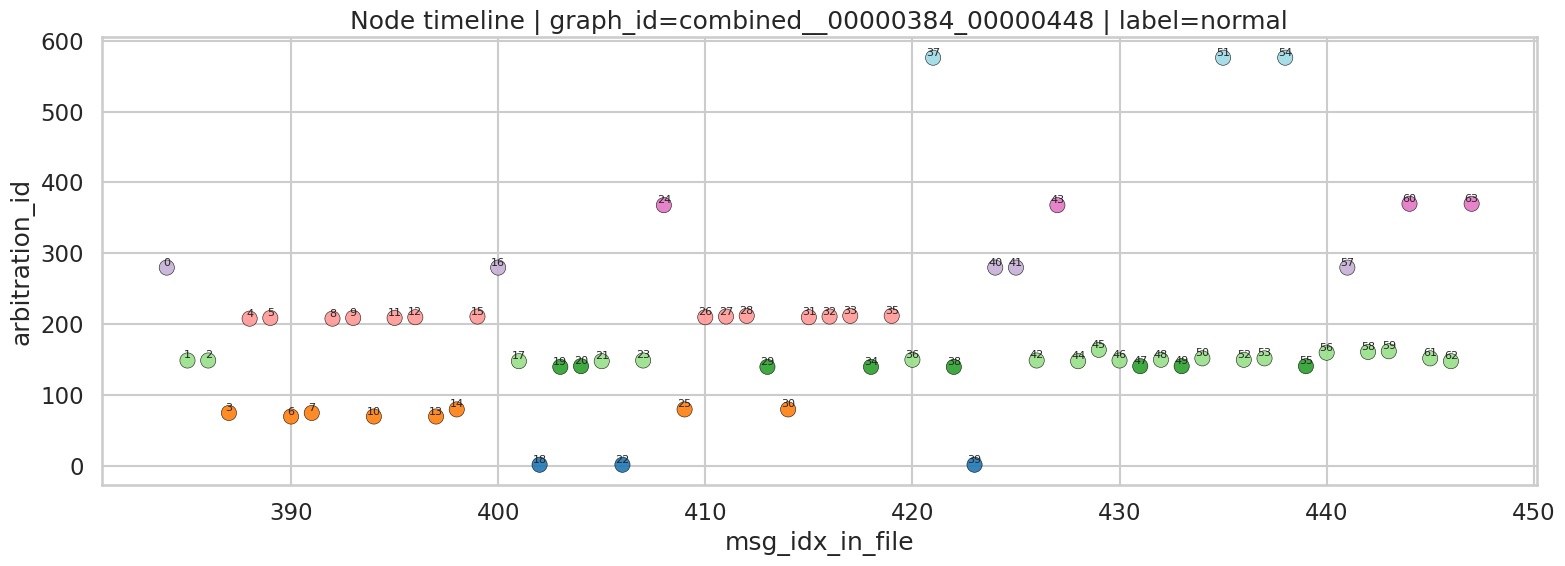

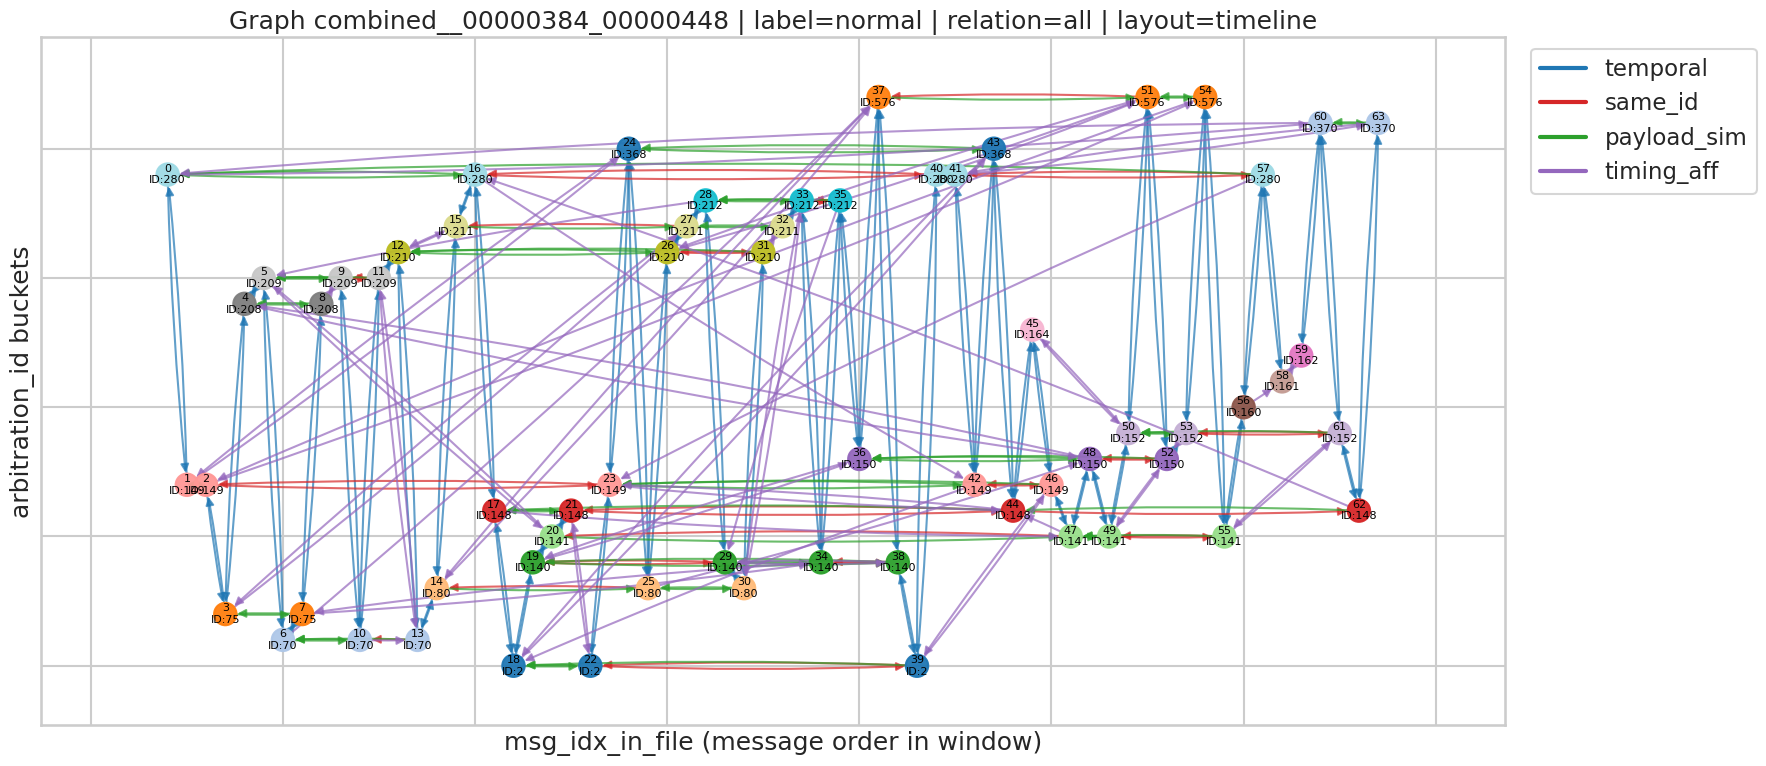

In [15]:
plot_message_timeline(graph)
plot_graph(graph, relation_filter=None, layout="timeline", figsize=(18, 8), node_size=260, font_size=8)
# plot_relation_panels(graph, layout="timeline", figsize=(20, 14))
# plot_relation_adjacency(graph)
# plot_edge_attr_distributions(graph)


In [24]:
# ============================================================
# FULL GRAPH - CLEAN / PUBLICATION STYLE
# dùng biến `graph` đã load sẵn trong notebook
# phụ thuộc các hàm đã có trong notebook:
# - graph_to_node_df(graph)
# - graph_to_edge_df(graph)
# - RELATION_COLORS
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

def plot_full_graph_clean(
    graph,
    show_labels=False,
    label_top_k=12,
    relation_filter=None,   # None hoặc list như ["temporal", "same_id"]
    figsize=(18, 9),
    node_size=90,
    edge_alpha=0.28,
    edge_width=1.4,
    temporal_alpha=0.35,
    other_alpha=0.22,
    annotate_mode="degree",   # "degree" hoặc "manual"
    manual_nodes=None,
):
    node_df = graph_to_node_df(graph).copy()
    edge_df = graph_to_edge_df(graph).copy()

    if relation_filter is not None:
        edge_df = edge_df[edge_df["edge_type_name"].isin(relation_filter)].copy()

    # node positions: timeline layout
    x = node_df["msg_idx_in_file"].to_numpy()
    if "arbitration_id_bucket" in node_df.columns:
        y = node_df["arbitration_id_bucket"].to_numpy()
    elif "id_bucket" in node_df.columns:
        y = node_df["id_bucket"].to_numpy()
    else:
        # fallback nếu notebook không có bucket
        if "arbitration_id" in node_df.columns:
            uniq_ids = sorted(node_df["arbitration_id"].unique())
            id_to_bucket = {v: i for i, v in enumerate(uniq_ids)}
            y = node_df["arbitration_id"].map(id_to_bucket).to_numpy()
        else:
            y = np.zeros(len(node_df))

    pos = {int(r.node_idx): (float(r.msg_idx_in_file), float(y_i))
           for r, y_i in zip(node_df.itertuples(), y)}

    fig, ax = plt.subplots(figsize=figsize)

    # --- edges ---
    relation_order = ["temporal", "same_id", "payload_sim", "timing_aff"]
    present_relations = [r for r in relation_order if r in edge_df["edge_type_name"].unique()]

    for rel in present_relations:
        sub = edge_df[edge_df["edge_type_name"] == rel]
        color = RELATION_COLORS.get(rel, "gray")
        alpha = temporal_alpha if rel == "temporal" else other_alpha

        for row in sub.itertuples():
            u = int(row.src)
            v = int(row.dst)
            if u not in pos or v not in pos:
                continue
            x1, y1 = pos[u]
            x2, y2 = pos[v]

            # temporal edge vẽ thẳng hơn, relation khác cong nhẹ
            if rel == "temporal":
                rad = 0.0
            elif rel == "same_id":
                rad = 0.03
            elif rel == "payload_sim":
                rad = -0.05
            else:
                rad = 0.08

            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=color,
                    lw=edge_width,
                    alpha=alpha,
                    shrinkA=6,
                    shrinkB=6,
                    mutation_scale=10,
                    connectionstyle=f"arc3,rad={rad}",
                ),
                zorder=1,
            )

    # --- nodes ---
    if "arbitration_id" in node_df.columns:
        cmap = plt.get_cmap("tab20")
        node_colors = [cmap(int(v) % 20) for v in node_df["arbitration_id"].fillna(0).astype(int)]
    else:
        node_colors = ["#4C78A8"] * len(node_df)

    ax.scatter(
        x, y,
        s=node_size,
        c=node_colors,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.95,
        zorder=3
    )

    # --- choose labels ---
    label_nodes = []
    if show_labels:
        if annotate_mode == "manual" and manual_nodes is not None:
            label_nodes = list(manual_nodes)
        else:
            # top-k node theo degree trong edge_df
            deg = pd.concat([
                edge_df["src"].value_counts(),
                edge_df["dst"].value_counts()
            ], axis=1).fillna(0).sum(axis=1)
            label_nodes = deg.sort_values(ascending=False).head(label_top_k).index.tolist()

    for n in label_nodes:
        row = node_df[node_df["node_idx"] == n]
        if len(row) == 0:
            continue
        row = row.iloc[0]
        xx = row["msg_idx_in_file"]
        yy = pos[int(n)][1]
        arb = row["arbitration_id"] if "arbitration_id" in row else "?"
        ax.text(
            xx, yy + 0.18,
            f"{int(n)}\nID:{arb}",
            fontsize=8,
            ha="center",
            va="bottom",
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.72),
            zorder=5,
        )

    # --- style ---
    graph_id = graph.get("graph_id", "unknown_graph")
    label_name = graph.get("label_name", graph.get("label", "unknown_label"))

    ax.set_title(
        f"Full graph overview | graph_id={graph_id} | label={label_name}",
        fontsize=18,
        pad=12
    )
    ax.set_xlabel("msg_idx_in_file (message order in window)", fontsize=15)
    ax.set_ylabel("arbitration_id buckets", fontsize=15)

    ax.grid(True, alpha=0.22, linestyle="--")
    ax.set_facecolor("white")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    handles = [
        Line2D([0], [0], color=RELATION_COLORS[r], lw=3, label=r)
        for r in present_relations
    ]
    if handles:
        ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=14)

    plt.tight_layout()
    plt.show()

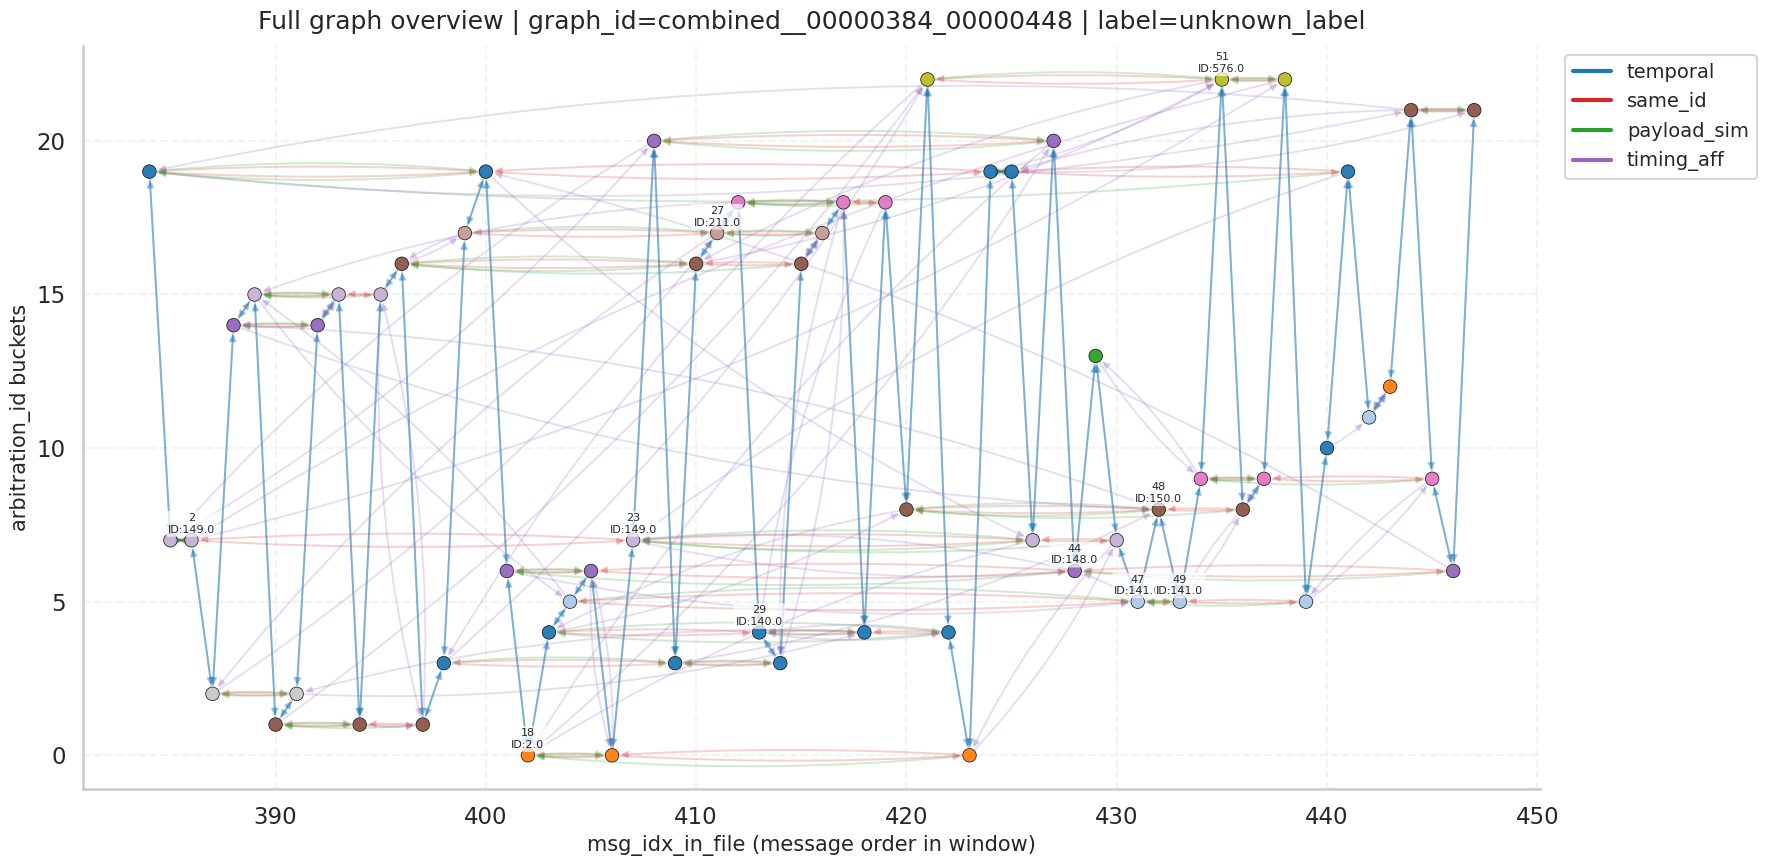

In [25]:
plot_full_graph_clean(
    graph,
    show_labels=True,
    label_top_k=10,
    figsize=(18, 9),
    node_size=95,
)

In [22]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

def plot_full_graph_small_multiples(
    graph,
    figsize=(20, 12),
    node_size=55,
    edge_width=1.1,
    show_node_labels=False,
):
    node_df = graph_to_node_df(graph).copy()
    edge_df = graph_to_edge_df(graph).copy()

    x = node_df["msg_idx_in_file"].to_numpy()

    if "arbitration_id_bucket" in node_df.columns:
        y = node_df["arbitration_id_bucket"].to_numpy()
    elif "id_bucket" in node_df.columns:
        y = node_df["id_bucket"].to_numpy()
    else:
        if "arbitration_id" in node_df.columns:
            uniq_ids = sorted(node_df["arbitration_id"].unique())
            id_to_bucket = {v: i for i, v in enumerate(uniq_ids)}
            y = node_df["arbitration_id"].map(id_to_bucket).to_numpy()
        else:
            y = np.zeros(len(node_df))

    pos = {
        int(r.node_idx): (float(r.msg_idx_in_file), float(y_i))
        for r, y_i in zip(node_df.itertuples(), y)
    }

    relation_panels = [
        ("all", None),
        ("temporal", ["temporal"]),
        ("same_id", ["same_id"]),
        ("payload_sim", ["payload_sim"]),
        ("timing_aff", ["timing_aff"]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    cmap = plt.get_cmap("tab20")
    if "arbitration_id" in node_df.columns:
        node_colors = [cmap(int(v) % 20) for v in node_df["arbitration_id"].fillna(0).astype(int)]
    else:
        node_colors = ["#4C78A8"] * len(node_df)

    for ax, (title, rels) in zip(axes, relation_panels):
        sub_edge_df = edge_df.copy()
        if rels is not None:
            sub_edge_df = sub_edge_df[sub_edge_df["edge_type_name"].isin(rels)].copy()

        # draw edges
        for row in sub_edge_df.itertuples():
            u = int(row.src)
            v = int(row.dst)
            rel = row.edge_type_name
            if u not in pos or v not in pos:
                continue

            x1, y1 = pos[u]
            x2, y2 = pos[v]

            if rel == "temporal":
                rad = 0.0
                alpha = 0.35
            elif rel == "same_id":
                rad = 0.03
                alpha = 0.28
            elif rel == "payload_sim":
                rad = -0.05
                alpha = 0.25
            else:
                rad = 0.08
                alpha = 0.25

            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=RELATION_COLORS.get(rel, "gray"),
                    lw=edge_width,
                    alpha=alpha,
                    shrinkA=5,
                    shrinkB=5,
                    mutation_scale=8,
                    connectionstyle=f"arc3,rad={rad}",
                ),
                zorder=1,
            )

        # draw nodes
        ax.scatter(
            x, y,
            s=node_size,
            c=node_colors,
            edgecolors="black",
            linewidths=0.35,
            alpha=0.95,
            zorder=3
        )

        if show_node_labels:
            for row, yy in zip(node_df.itertuples(), y):
                ax.text(
                    row.msg_idx_in_file,
                    yy + 0.1,
                    str(int(row.node_idx)),
                    fontsize=6,
                    ha="center",
                    va="bottom",
                    zorder=5
                )

        ax.set_title(title, fontsize=14)
        ax.grid(True, alpha=0.18, linestyle="--")

    # hide extra axes
    if len(axes) > len(relation_panels):
        for k in range(len(relation_panels), len(axes)):
            axes[k].axis("off")

    graph_id = graph.get("graph_id", "unknown_graph")
    label_name = graph.get("label_name", graph.get("label", "unknown_label"))

    fig.suptitle(
        f"Whole-graph visualization by relation | graph_id={graph_id} | label={label_name}",
        fontsize=18,
        y=0.98
    )

    for ax in axes[:len(relation_panels)]:
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    axes[4].set_xlabel("msg_idx_in_file", fontsize=13)
    axes[3].set_ylabel("arbitration_id buckets", fontsize=13)

    plt.tight_layout()
    plt.show()

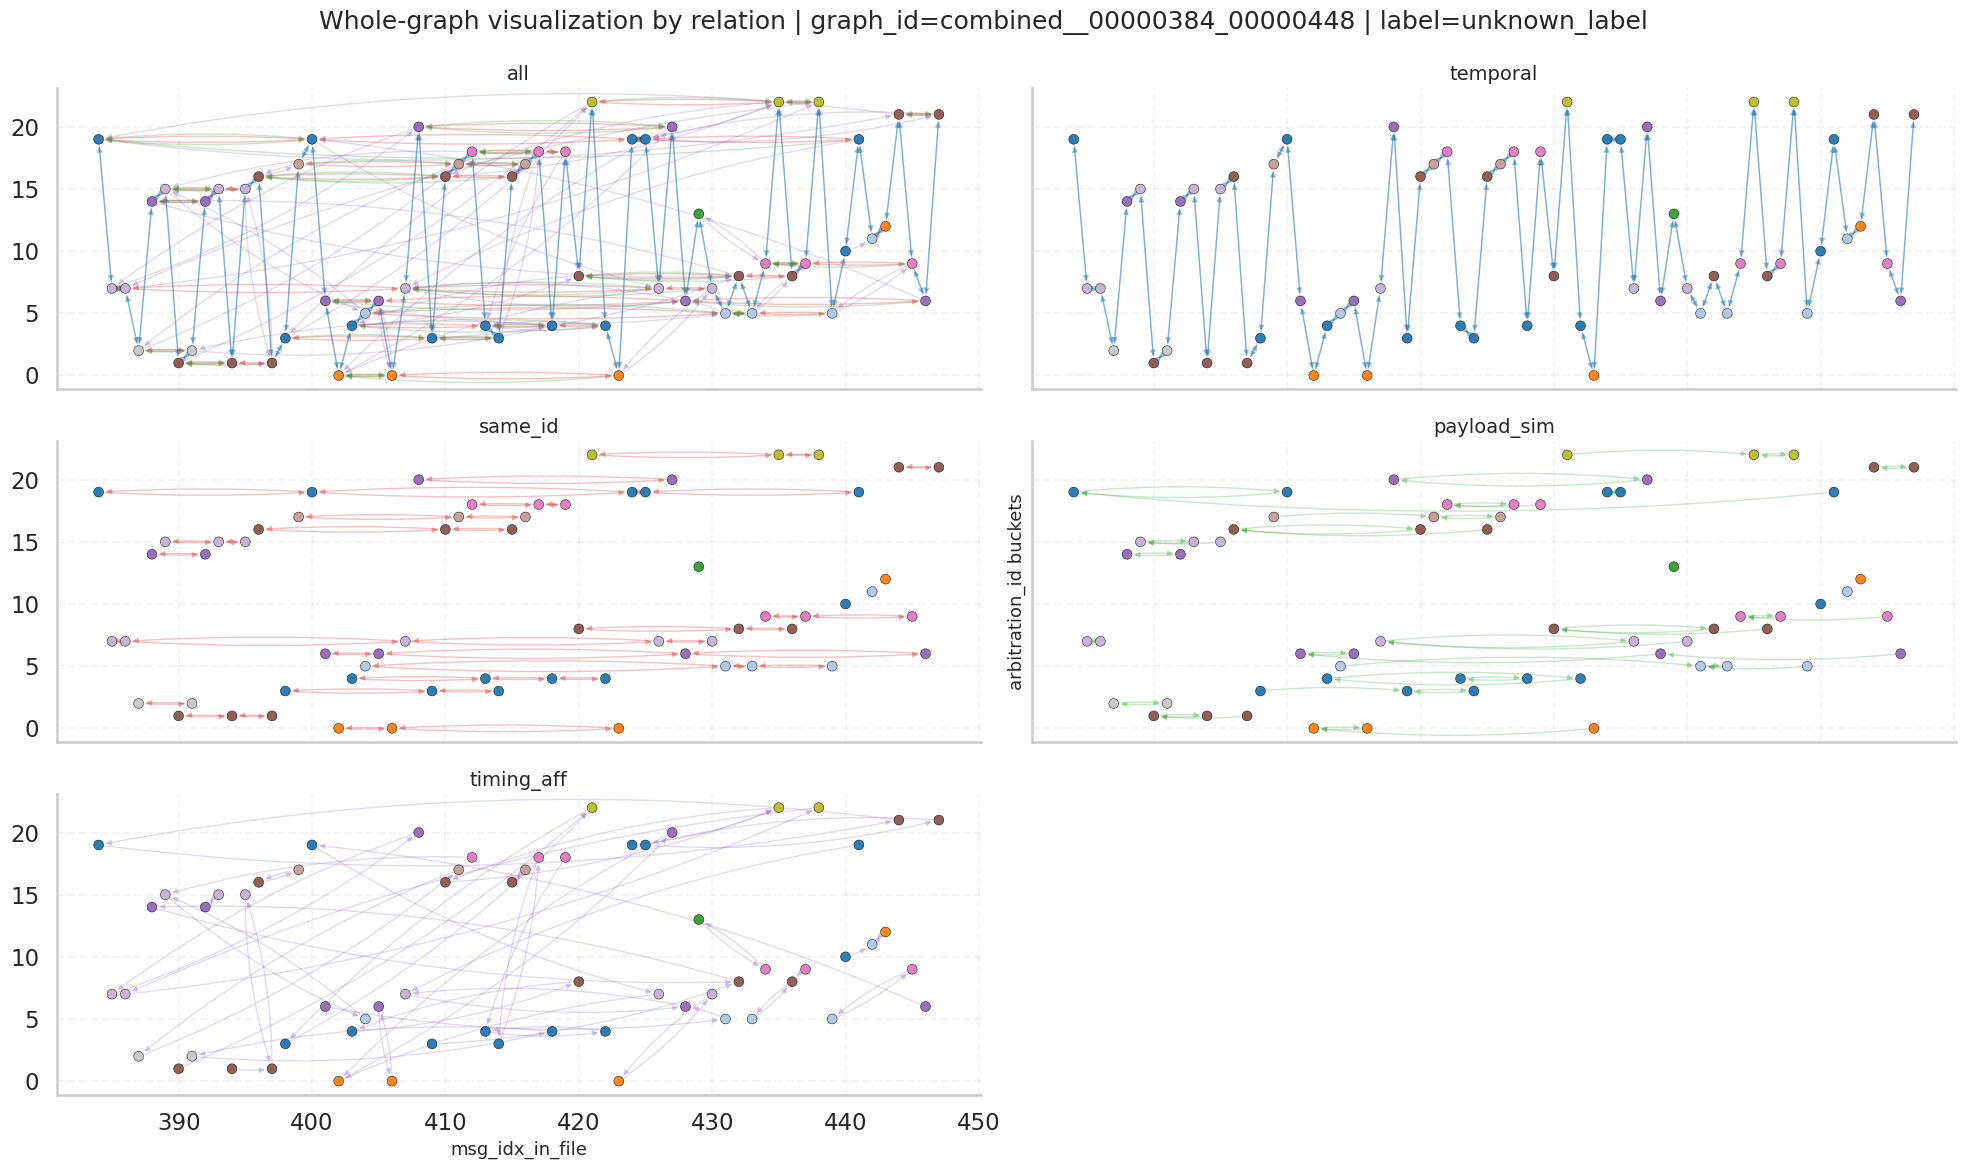

In [23]:
plot_full_graph_small_multiples(
    graph,
    figsize=(20, 12),
    node_size=50,
    edge_width=1.0,
    show_node_labels=False,
)

## 10. Ví dụ ego-subgraph

/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages/matplotlib/cbook.py:1072: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x = np.asanyarray(x)


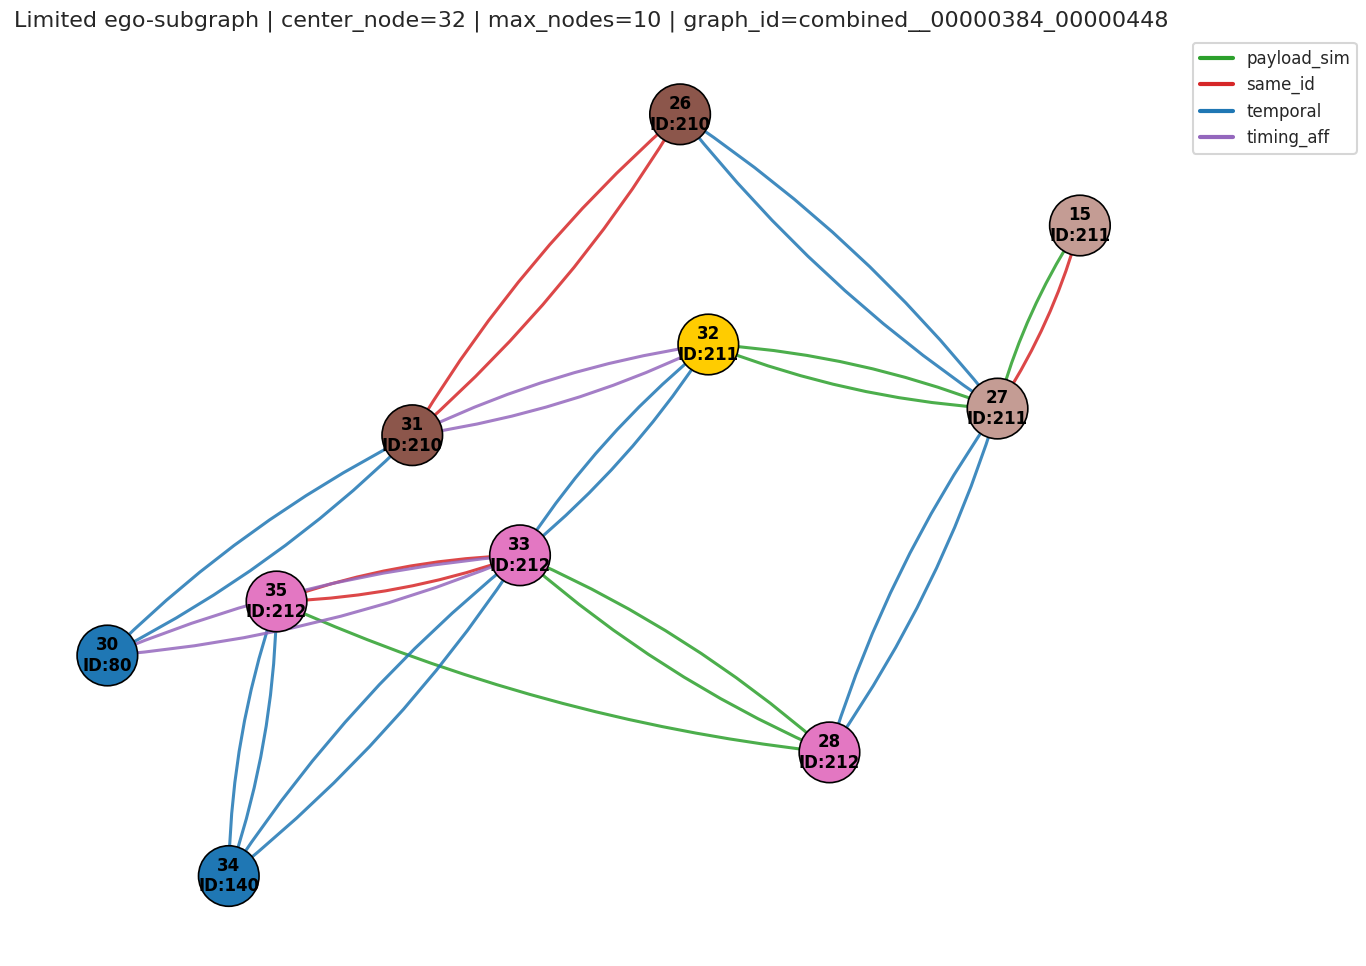

Selected nodes (10): [32, 31, 33, 27, 30, 34, 35, 28, 26, 15]


In [16]:
center_node = 32
plot_ego_subgraph_limited(
    graph,
    center_node=center_node,
    max_nodes=10,
    relation_filter=None,
    layout="spring",
    figsize=(14, 10),
    node_size=1900,
    font_size=12,
    label_mode="id_only",
)

## 11. So sánh nhanh nhiều graph cùng class hoặc khác class

In [18]:
def compare_graphs(split="test", labels=None, n_per_label=1, seed=42):
    rng = np.random.default_rng(seed)
    df = load_graph_index(split)

    if labels is None:
        labels = sorted(df["window_label"].unique().tolist())

    chosen = []
    for label in labels:
        sub = df[df["window_label"] == label].copy()
        if len(sub) == 0:
            continue
        k = min(n_per_label, len(sub))
        take = sub.sample(k, random_state=seed)
        chosen.append(take)

    out = pd.concat(chosen, ignore_index=True)
    return out[["graph_id", "split", "window_label", "source_class", "num_nodes", "num_edges", "attack_ratio", "shard_id"]]

compare_df = compare_graphs(split=DEFAULT_SPLIT, labels=["normal", "combined", "rpm", "speed"], n_per_label=2, seed=7)
display(compare_df)


,graph_id,split,window_label,source_class,num_nodes,num_edges,attack_ratio,shard_id
0,combined__05533120_05533184,test,normal,combined,64,300,0.000000,3
1,combined__00109824_00109888,test,normal,combined,64,326,0.000000,0
2,combined__01795328_01795392,test,combined,combined,64,319,0.109375,1
3,combined__02287936_02288000,test,combined,combined,64,321,0.078125,1
4,rpm__01239168_01239232,test,rpm,rpm,64,317,0.015625,10
5,rpm__00371456_00371520,test,rpm,rpm,64,321,0.062500,10
6,speed__03004096_03004160,test,speed,speed,64,309,0.046875,13
7,speed__02206976_02207040,test,speed,speed,64,316,0.046875,12


## 12. Optional: interactive browser bằng ipywidgets

In [19]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    available_splits = [s for s in ["train", "val", "test"] if (GRAPH_ROOT / f"graph_index_{s}.parquet").exists() or (GRAPH_ROOT / f"graph_index_{s}.csv").exists()]
    split_widget = widgets.Dropdown(options=available_splits, value=DEFAULT_SPLIT, description="split")
    label_widget = widgets.Dropdown(options=["<all>"], value="<all>", description="label")
    index_widget = widgets.IntSlider(value=0, min=0, max=10, step=1, description="idx")
    out = widgets.Output()

    def refresh_label_options(*args):
        df = load_graph_index(split_widget.value)
        opts = ["<all>"] + sorted(df["window_label"].unique().tolist())
        label_widget.options = opts
        refresh_index_range()

    def refresh_index_range(*args):
        df = load_graph_index(split_widget.value)
        if label_widget.value != "<all>":
            df = df[df["window_label"] == label_widget.value].reset_index(drop=True)
        index_widget.max = max(0, len(df) - 1)
        index_widget.value = min(index_widget.value, index_widget.max)

    def render(*args):
        with out:
            clear_output(wait=True)
            df = load_graph_index(split_widget.value).reset_index(drop=True)
            if label_widget.value != "<all>":
                df = df[df["window_label"] == label_widget.value].reset_index(drop=True)
            if len(df) == 0:
                print("No graph found")
                return
            row = df.iloc[index_widget.value]
            graph = load_graph_from_index_row(row)
            summarize_graph(graph)
            plot_message_timeline(graph)
            plot_graph(graph, relation_filter=None, layout="timeline", figsize=(16, 7), node_size=220, font_size=7)

    split_widget.observe(refresh_label_options, names="value")
    label_widget.observe(refresh_index_range, names="value")
    split_widget.observe(render, names="value")
    label_widget.observe(render, names="value")
    index_widget.observe(render, names="value")

    refresh_label_options()
    render()

    display(widgets.VBox([
        widgets.HBox([split_widget, label_widget]),
        index_widget,
        out
    ]))

except Exception as e:
    print("ipywidgets not available or failed to initialize:", e)


## 13. Gợi ý cách dùng notebook này cho phân tích mô hình

Bạn có thể dùng notebook này để trả lời các câu hỏi rất thực tế:

1. **Relation nào đang chi phối graph?**  
   Xem bảng `Edge count by relation` và panel từng relation.

2. **same_id edges có thật sự nối các message lặp ID như mong đợi không?**  
   Xem `plot_relation_panels(..., relation='same_id')` và `node table`.

3. **payload similarity đang nối những node nào?**  
   Xem `payload_sim` panel và edge table, đặc biệt các cột:
   - `payload_l1_norm`
   - `payload_hamming_norm`

4. **timing affinity có đang nối quá rộng hoặc quá nhiễu không?**  
   Xem:
   - `timing_aff` panel
   - histogram `timing_diff_abs`

5. **temporal relation có đúng thứ tự message không?**  
   Xem:
   - `plot_message_timeline`
   - `temporal` panel
   - adjacency matrix của `temporal`

6. **một node cụ thể đang được nối bởi những relation nào?**  
   Xem `plot_ego_subgraph(...)`.

Nếu bạn muốn, bước tiếp theo mình có thể tạo thêm **notebook thứ hai** để:
- overlay **attention/gate weights** từ model lên graph,
- hoặc visualize **embedding / saliency / top suspicious edges** từ mô hình GNN hiện tại.
